In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os


def parse_log_data(file_path):
    """
    解析日志文件
    返回:
    1. pg_data: {sql_name: time} (PG的基准时间)
    2. bao_history: {sql_name: [time1, time2, ...]} (BAO的历史运行时间列表)
    """
    pg_data = {}
    bao_history = {}

    if not os.path.exists(file_path):
        print(f"错误: 找不到文件 {file_path}")
        return None, None

    print(f"正在读取 {file_path} ...")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            
            # -------------------------------------------
            # 1. 解析 PG 数据 (x x [sql] [time] PG)
            # -------------------------------------------
            if len(parts) >= 4 and parts[-1] == 'PG':
                sql_name = parts[2]
                try:
                    time_val = float(parts[3])
                    pg_data[sql_name] = time_val
                except ValueError:
                    continue

            # -------------------------------------------
            # 2. 解析 BAO 数据 (BAO [sql] [time])
            # -------------------------------------------
            elif len(parts) >= 3 and parts[0] == 'BAO':
                sql_name = parts[1]
                try:
                    time_val = float(parts[2])
                    
                    # 核心逻辑：如果key不存在，初始化为空列表；存在则append
                    if sql_name not in bao_history:
                        bao_history[sql_name] = []
                    
                    bao_history[sql_name].append(time_val)
                    
                except ValueError:
                    continue
    
    return pg_data, bao_history

def plot_latest_comparison(pg_data, bao_history):
    """
    图表 1: 最新的 BAO 预测 vs PG 对比柱状图
    """
    # 找出交集（PG跑过 且 BAO至少跑过一次的）
    common_sqls = sorted(list(set(pg_data.keys()) & set(bao_history.keys())))
    
    if not common_sqls:
        print("没有可对比的数据（未找到共有的SQL）。")
        return

    print(f"正在生成【最新状态对比图】，包含 {len(common_sqls)} 个查询...")

    pg_times = []
    bao_latest_times = []

    for sql in common_sqls:
        pg_times.append(pg_data[sql])
        # 取列表的最后一个元素 [-1]，即“最新”的一次时间
        bao_latest_times.append(bao_history[sql][-1])

    # 绘图设置
    x = np.arange(len(common_sqls))
    width = 0.35

    plt.figure(figsize=(16, 8))
    plt.bar(x - width/2, pg_times, width, label='PostgreSQL (Default)', color='#1f77b4', alpha=0.8)
    plt.bar(x + width/2, bao_latest_times, width, label='BAO (Latest Prediction)', color='#ff7f0e', alpha=0.8)

    plt.xlabel('SQL Query', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.title('Performance Comparison: PG vs Latest BAO Result', fontsize=16)
    plt.xticks(x, common_sqls, rotation=90, fontsize=8)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    save_name = '1_latest_comparison.png'
    plt.savefig(save_name)
    print(f"-> 图表 1 已保存: {save_name}")
    plt.show()

def plot_sql_trends(pg_data, bao_history, target_sqls):
    """
    图表 2: 指定 SQL 的运行时间折线图
    横坐标: 第几次运行 (1, 2, 3...)
    纵坐标: 运行时间
    """
    print(f"正在生成【趋势折线图】，目标: {target_sqls} ...")
    
    plt.figure(figsize=(14, 8))
    colors = ['#d62728', '#2ca02c', '#9467bd', '#8c564b', '#e377c2'] # 备选颜色
    
    found_any = False

    for i, sql in enumerate(target_sqls):
        if sql not in bao_history:
            print(f"警告: {sql} 在 BAO 历史记录中未找到，跳过。")
            continue
        
        found_any = True
        times_list = bao_history[sql]
        
        # 横坐标：第1次, 第2次, ..., 第N次
        x_axis = list(range(1, len(times_list) + 1))
        
        color = colors[i % len(colors)]
        
        # 画折线 (BAO)
        plt.plot(x_axis, times_list, marker='o', linestyle='-', linewidth=2, 
                 color=color, label=f'{sql} (BAO Trend)')
        
        # 画参考线 (PG) - 如果存在的话
        if sql in pg_data:
            pg_time = pg_data[sql]
            plt.axhline(y=pg_time, color=color, linestyle='--', alpha=0.5, linewidth=1.5)
            # 在最右侧标注 PG 时间
            plt.text(x_axis[-1], pg_time, f' PG Base', 
                     color=color, fontsize=9, verticalalignment='bottom')

    if not found_any:
        return

    plt.xlabel('Execution Count (N-th time executed by BAO)', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.title('Optimization Trend per SQL (Counts vs Time)', fontsize=16)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    save_name = '2_execution_trend.png'
    plt.savefig(save_name)
    print(f"-> 图表 2 已保存: {save_name}")
    plt.show()

In [5]:
# ================= 配置区域 =================
LOG_FILE = "log_comp.txt"


# ===========================================

# 1. 解析数据
pg_dict, bao_dict = parse_log_data(LOG_FILE)




正在读取 log_comp.txt ...


正在生成【最新状态对比图】，包含 112 个查询...
-> 图表 1 已保存: 1_latest_comparison.png


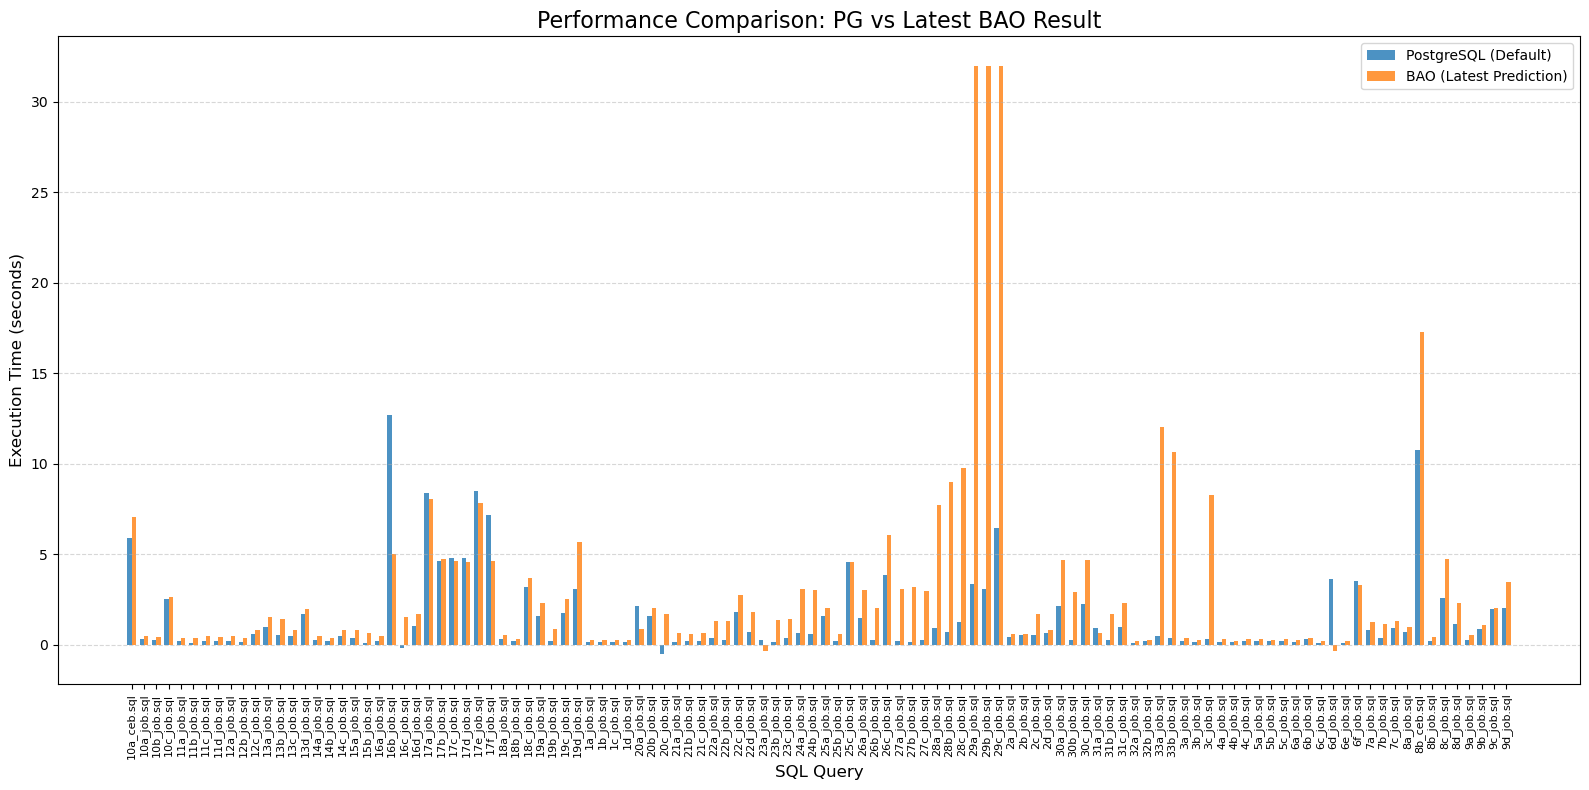

In [ ]:
# 2. 画第一张图：最新对比
plot_latest_comparison(pg_dict, bao_dict)

正在生成【趋势折线图】，目标: ['1a_job.sql', '2b_job.sql', '1c_job.sql'] ...
-> 图表 2 已保存: 2_execution_trend.png


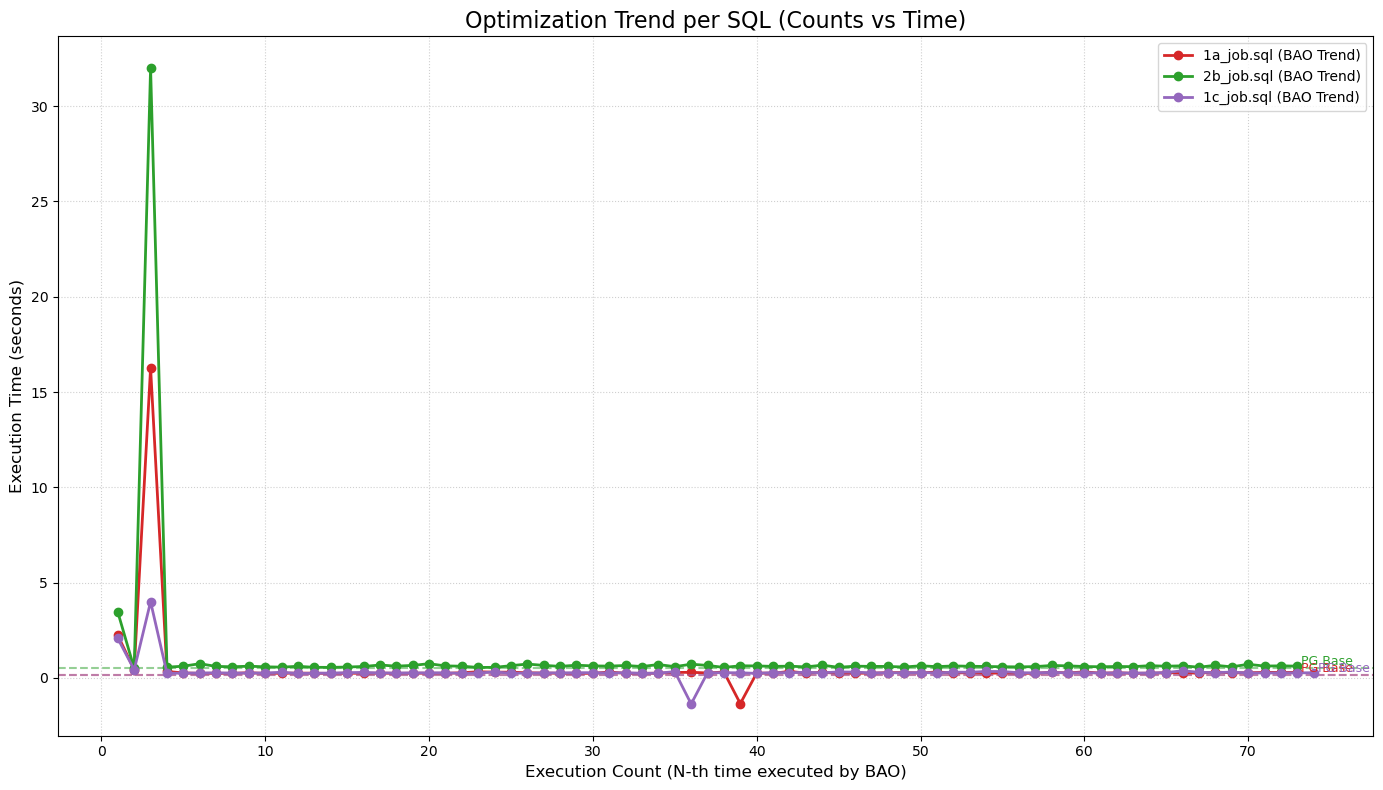

In [ ]:
# 你想在【图表2】中查看趋势的具体 SQL 列表
# 可以根据需要修改这里
TARGET_TREND_SQLS = [
    # "1a_job.sql",
    "2b_job.sql",
    # "1c_job.sql",
]
# 3. 画第二张图：指定SQL的趋势
plot_sql_trends(pg_dict, bao_dict, TARGET_TREND_SQLS)

In [14]:
print(len(pg_dict.keys()))
print(len(bao_dict.keys()))
print(bao_dict.keys())
num = []
for key, value in bao_dict.items():
    num.append(len(value))
print(num)
num = []
for key, value in pg_dict.items():
    num.append(value)
print(num)


112
197
dict_keys(['22a_job.sql', '18b_job.sql', '17b_job.sql', '1b_job.sql', '7b_job.sql', '16b_job.sql', '12c_job.sql', '23b_job.sql', '19c_job.sql', '22b_job.sql', '6c_job.sql', '31b_job.sql', '32a_job.sql', '31a_job.sql', '21a_job.sql', '11c_job.sql', '30b_job.sql', '24a_job.sql', '2a_job.sql', '19d_job.sql', '3b_job.sql', '10a_job.sql', '23c_job.sql', '28c_job.sql', '22d_job.sql', '14a_job.sql', '13b_job.sql', '9c_job.sql', '30c_job.sql', '29c_job.sql', '27b_job.sql', '11d_job.sql', '7a_job.sql', '33b_job.sql', '4c_job.sql', '6f_job.sql', '27a_job.sql', '16c_job.sql', '23a_job.sql', '10a_ceb.sql', '29b_job.sql', '2c_job.sql', '28b_job.sql', '17e_job.sql', '25c_job.sql', '6d_job.sql', '8b_ceb.sql', '16d_job.sql', '9b_job.sql', '1c_job.sql', '13d_job.sql', '27c_job.sql', '17c_job.sql', '8d_job.sql', '8a_job.sql', '9a_job.sql', '16a_job.sql', '1d_job.sql', '30a_job.sql', '12b_job.sql', '5c_job.sql', '25b_job.sql', '24b_job.sql', '6a_job.sql', '21b_job.sql', '26a_job.sql', '10b_job.sq

In [10]:
pg_dict['18b_job.sql']

2.7661337852478027